In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df= pd.read_csv(r"C:\Users\CCP\OneDrive\Desktop\Business Analytics\ZOMATO(1).zip")
df.head()

,Restaurant_Name,Dining_Rating,Delivery_Rating,Dining Votes,Delivery_Votes,Cuisine,Place_Name,City,Item_Name,Best_Seller,Votes,Prices
0,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Platter Kebab Combo,BESTSELLER,84,249.0
1,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken Rumali Shawarma,BESTSELLER,45,129.0
2,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken Tandoori Salad,NaN,39,189.0
3,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken BBQ Salad,BESTSELLER,43,189.0
4,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Special Doner Wrap Combo,MUST TRY,31,205.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123657 entries, 0 to 123656
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Restaurant_Name  123657 non-null  object 
 1   Dining_Rating    91421 non-null   float64
 2   Delivery_Rating  122377 non-null  float64
 3   Dining Votes     123657 non-null  int64  
 4   Delivery_Votes   123657 non-null  int64  
 5   Cuisine          123657 non-null  object 
 6   Place_Name       123657 non-null  object 
 7   City             123657 non-null  object 
 8   Item_Name        123657 non-null  object 
 9   Best_Seller      27942 non-null   object 
 10  Votes            123657 non-null  int64  
 11  Prices           123657 non-null  float64
dtypes: float64(3), int64(3), object(6)
memory usage: 11.3+ MB


In [5]:
df.isnull().sum()

Restaurant_Name        0
Dining_Rating      32236
Delivery_Rating     1280
Dining Votes           0
Delivery_Votes         0
Cuisine                0
Place_Name             0
City                   0
Item_Name              0
Best_Seller        95715
Votes                  0
Prices                 0
dtype: int64

In [8]:
df.drop_duplicates(inplace=True)

In [7]:
print(df.columns)

Index(['Restaurant_Name', 'Dining_Rating', 'Delivery_Rating', 'Dining Votes',
       'Delivery_Votes', 'Cuisine ', 'Place_Name', 'City', 'Item_Name',
       'Best_Seller', 'Votes', 'Prices'],
      dtype='object')


In [9]:
df["City"].value_counts()

City
Hyderabad       13100
Mumbai          11640
Chennai         11147
Jaipur          11009
Bangalore        9450
Ahmedabad        8519
Kolkata          6955
Pune             6655
Kochi            6281
Raipur           6272
Lucknow          5143
New Delhi        2852
Goa              2287
Banaswadi          85
Ulsoor             59
Magrath Road       45
Malleshwaram       31
Name: count, dtype: int64

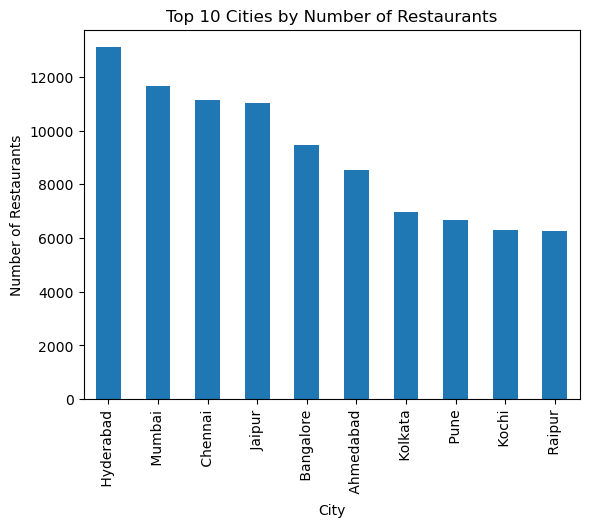

In [10]:
df["City"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Cities by Number of Restaurants")
plt.xlabel("City")
plt.ylabel("Number of Restaurants")
plt.show()

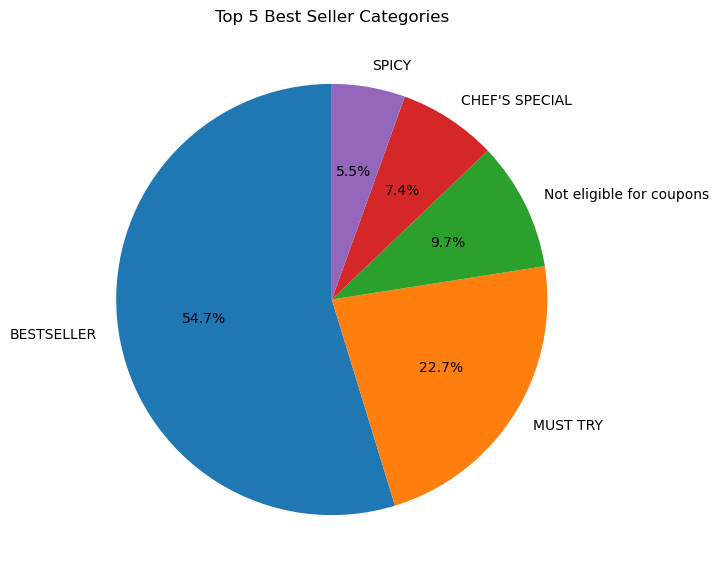

In [16]:
best = df["Best_Seller"].value_counts().head(5)

plt.figure(figsize=(7,7))
plt.pie(best,
        labels=best.index,
        autopct="%1.1f%%",
        startangle=90)

plt.title("Top 5 Best Seller Categories")
plt.show()

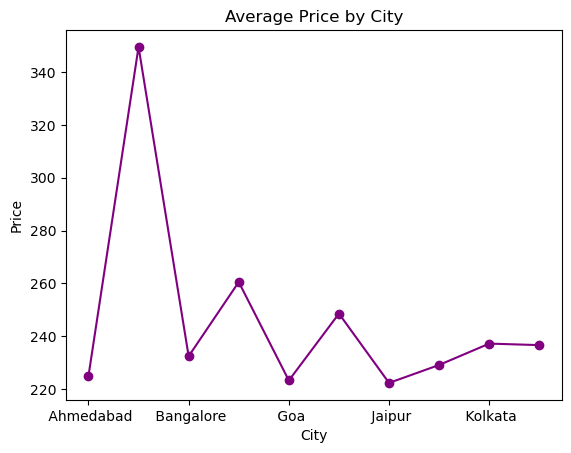

In [15]:
price = df.groupby("City")["Prices"].mean().head(10)

price.plot(kind="line", marker="o", color="purple")

plt.title("Average Price by City")
plt.xlabel("City")
plt.ylabel("Price")
plt.show()

In [28]:
# BUSINESS ANALYSIS REPORT

print("========== BUSINESS ANALYSIS REPORT ==========\n")

# Question 1
avg_dining = df['Dining_Rating'].mean()
print("Q1. What is the average dining rating of all restaurants?")
print(f"Answer: The average dining rating of all restaurants is {avg_dining:.2f}/5.\n")

# Question 2
most_common_cuisine = df['Cuisine '].value_counts().idxmax()
count = df['Cuisine '].value_counts().max()
print("Q2. Which cuisine is the most popular in the dataset?")
print(f"Answer: {most_common_cuisine} is the most common cuisine with {count} restaurants.\n")

# Question 3
city_delivery = df.groupby('City')['Delivery_Rating'].mean()
best_city = city_delivery.idxmax()
best_rating = city_delivery.max()
print("Q3. Which city has the highest average delivery rating?")
print(f"Answer: {best_city} has the highest average delivery rating of {best_rating:.2f}/5.\n")

# Question 4
df['Total_Votes'] = df['Dining Votes'] + df['Delivery_Votes']
top_restaurant = df.groupby('Restaurant_Name')['Total_Votes'].sum()
restaurant = top_restaurant.idxmax()
votes = top_restaurant.max()
print("Q4. Which restaurant has received the highest customer engagement?")
print(f"Answer: {restaurant} has the highest customer engagement with {votes:,} total votes.\n")
# Question 5
avg_price = df['Prices'].mean()
print("Q5. What is the average price of menu items across all restaurants?")
print(f"Answer: The average price of menu items across all restaurants is ₹{avg_price:.2f}.")


========== BUSINESS ANALYSIS REPORT ==========

Q1. What is the average dining rating of all restaurants?
Answer: The average dining rating of all restaurants is 3.82/5.

Q2. Which cuisine is the most popular in the dataset?
Answer: Beverages is the most common cuisine with 32818 restaurants.

Q3. Which city has the highest average delivery rating?
Answer:  Pune has the highest average delivery rating of 4.02/5.

Q4. Which restaurant has received the highest customer engagement?
Answer: Burger King has the highest customer engagement with 525,173 total votes.

Q5. What is the average price of menu items across all restaurants?
Answer: The average price of menu items across all restaurants is ₹243.69.


In [33]:
print("\nOverall Conclusion:")
print("The analysis shows that customer ratings, cuisine popularity, delivery performance, and customer engagement provide valuable insights into restaurant business performance. Beverages is the most popular cuisine, Pune has the highest average delivery rating, and Burger King has the highest customer engagement. These findings can help restaurant owners improve their services, pricing strategies, and overall customer satisfaction.")


Overall Conclusion:
The analysis shows that customer ratings, cuisine popularity, delivery performance, and customer engagement provide valuable insights into restaurant business performance. Beverages is the most popular cuisine, Pune has the highest average delivery rating, and Burger King has the highest customer engagement. These findings can help restaurant owners improve their services, pricing strategies, and overall customer satisfaction.
